In [32]:
import pandas as pd
import matplotlib.pyplot as plt

readData = pd.read_csv("data/read.csv")
threadData = pd.read_csv("data/thread_test.csv")

#### To do:
<ul>
    <li> Add colour scheme for interface width and packing modes to standardise colours to make it easy to view
    <li> Computing load impact
</ul>

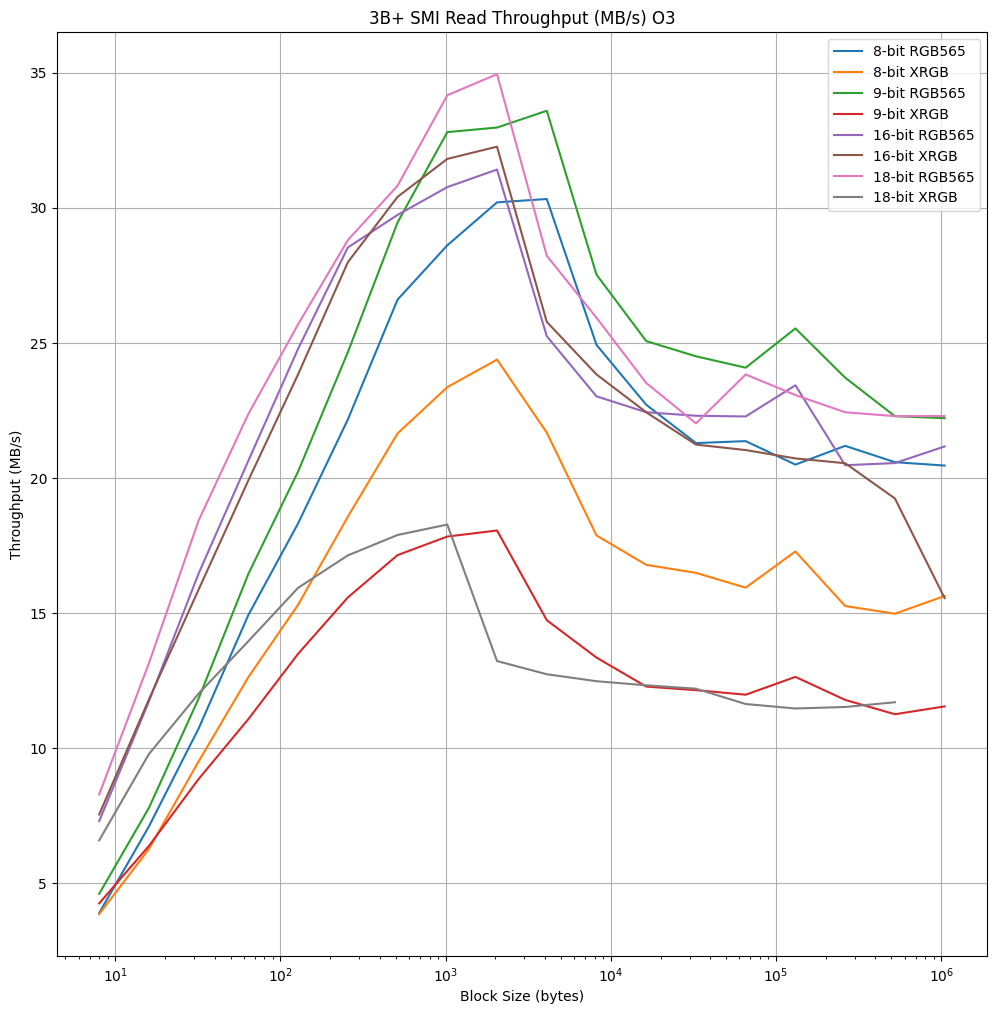

In [33]:
plt.figure(figsize=(12, 12))

filtered = readData[
    (readData["Device"] == "RPI3B+") &
    (readData["Optimisation"] == "O3")
]

for key, group in filtered.groupby(["Width","Pack"]):

    group = group.sort_values("Block")

    label = f"{key[0]}-bit {key[1]}"

    x = group["Block"]
    y = group["MBps"]
    plt.plot(x, y, label=label)

plt.xscale("log")
plt.xlabel("Block Size (bytes)")
plt.ylabel("Throughput (MB/s)")
plt.title("3B+ SMI Read Throughput (MB/s) O3")
plt.legend()
plt.grid(True)

plt.show()

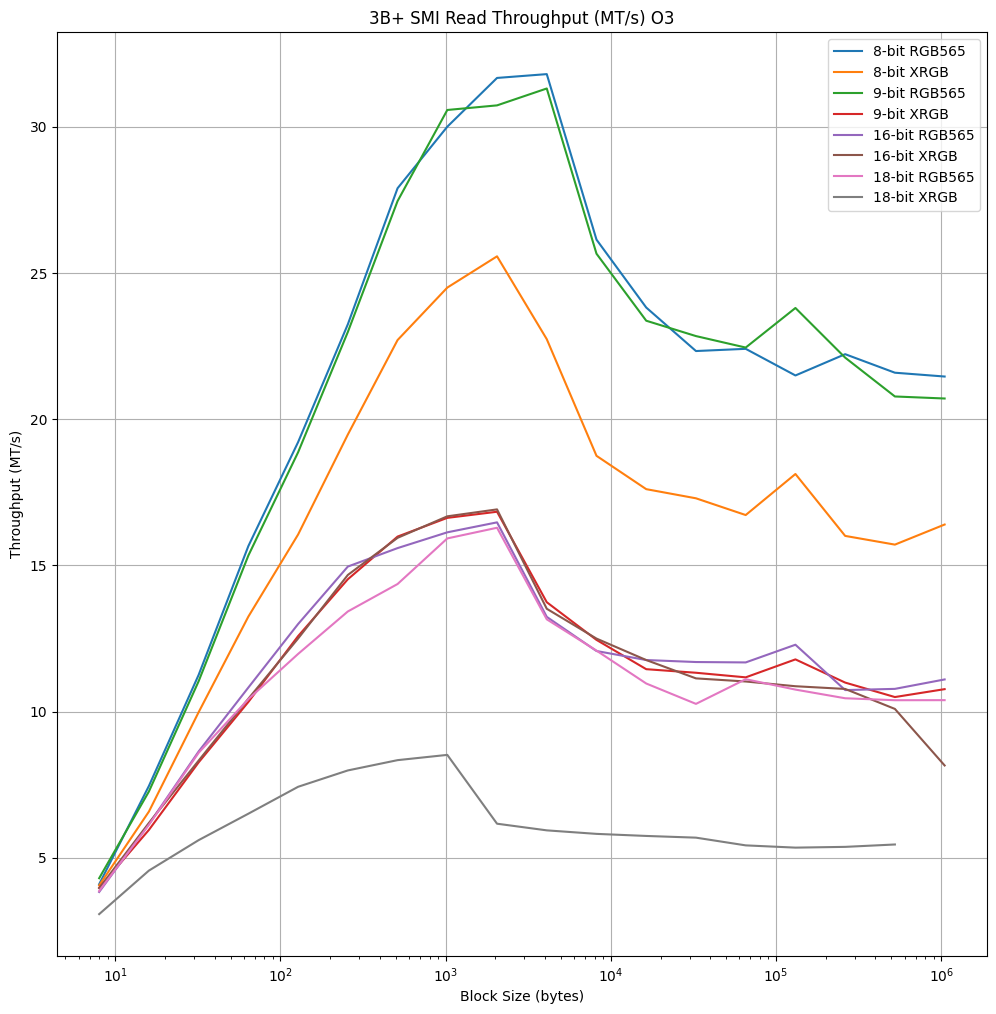

In [34]:
plt.figure(figsize=(12, 12))
filtered = readData[
    (readData["Device"] == "RPI3B+") &
    (readData["Optimisation"] == "O3")
]

for key, group in filtered.groupby(["Width","Pack"]):

    group = group.sort_values("Block")

    label = f"{key[0]}-bit {key[1]}"

    x = group["Block"]
    y = group["MTps"]


    plt.plot(x, y, label=label)

plt.xscale("log")
plt.xlabel("Block Size (bytes)")
plt.ylabel("Throughput (MT/s)")
plt.title("3B+ SMI Read Throughput (MT/s) O3")
plt.legend()
plt.grid(True)

plt.show()

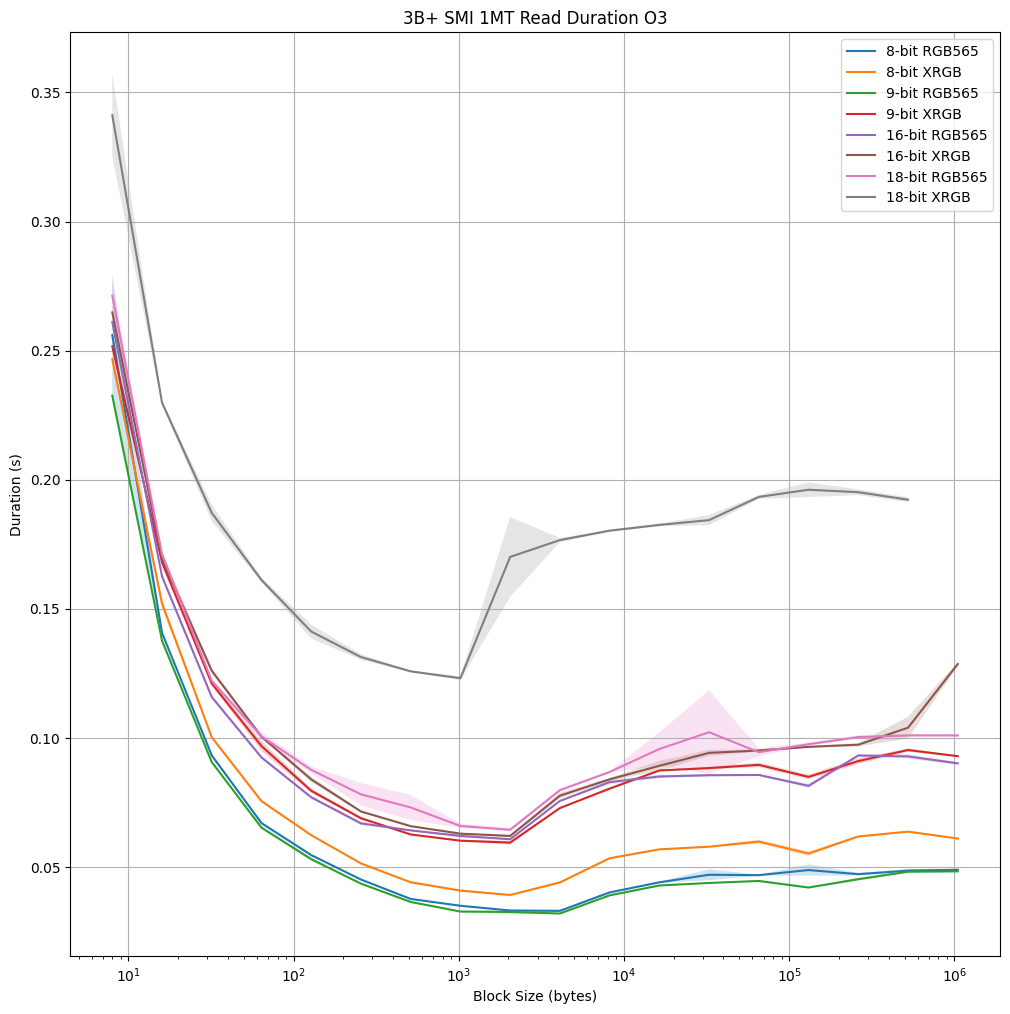

In [35]:
plt.figure(figsize=(12, 12))

filtered = readData[
    (readData["Device"] == "RPI3B+") &
    (readData["Optimisation"] == "O3")
]

for key, group in filtered.groupby(["Width","Pack"]):

    group = group.sort_values("Block")

    label = f"{key[0]}-bit {key[1]}"

    x = group["Block"]
    y = group["avg_time_s"]

    yerr = group["stdev_s"]

    plt.plot(x, y, label=label)

    plt.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.2
    )

plt.xscale("log")
plt.xlabel("Block Size (bytes)")
plt.ylabel("Duration (s)")
plt.title("3B+ SMI 1MT Read Duration O3")
plt.legend()
plt.grid(True)

plt.show()

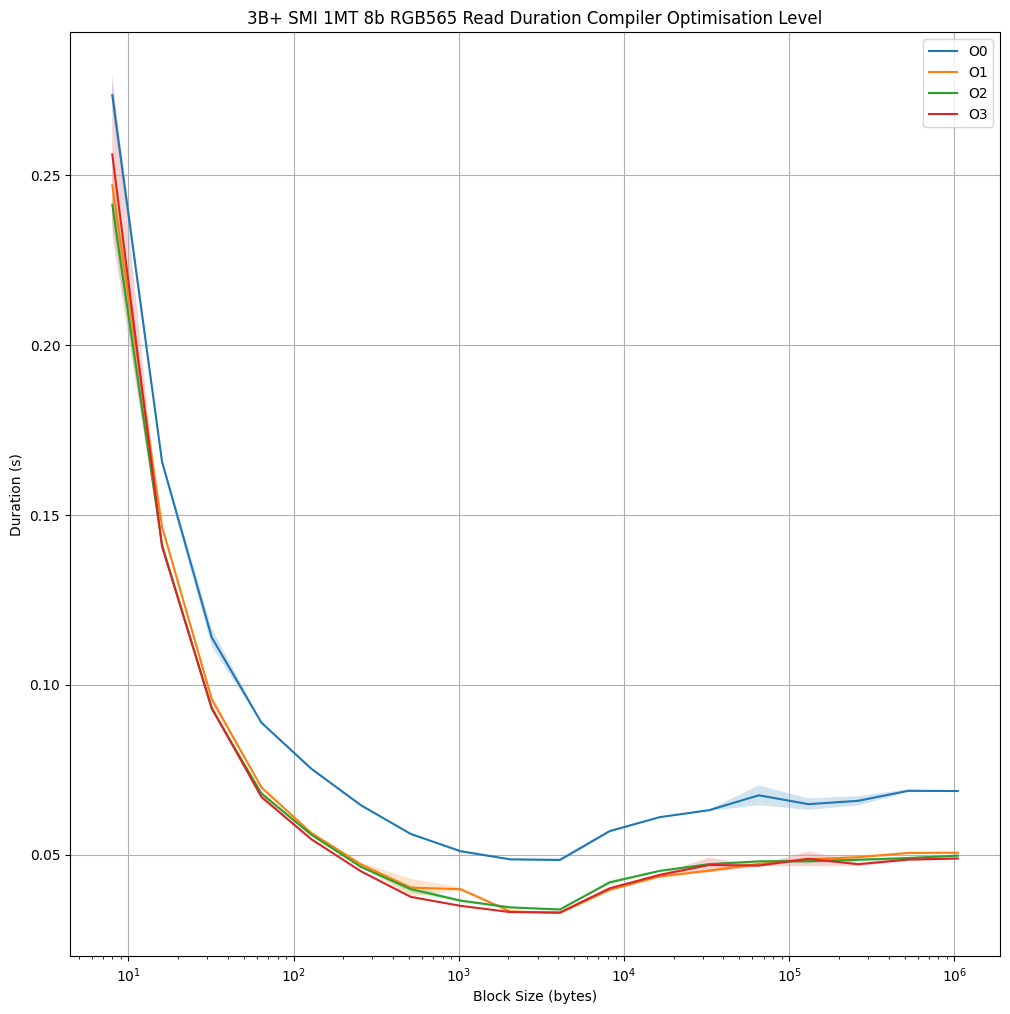

In [36]:
plt.figure(figsize=(12, 12))

filtered = readData[
    (readData["Device"] == "RPI3B+") &
    (readData["Width"] == 8) &
    (readData["Pack"] == "RGB565")
]

for key, group in filtered.groupby(["Optimisation"]):

    group = group.sort_values("Block")

    label = key

    x = group["Block"]
    y = group["avg_time_s"]
    yerr = group["stdev_s"]

    plt.plot(x, y, label=label)

    plt.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.2
    )

plt.xscale("log")
plt.xlabel("Block Size (bytes)")
plt.ylabel("Duration (s)")
plt.title("3B+ SMI 1MT 8b RGB565 Read Duration Compiler Optimisation Level")
plt.legend()
plt.grid(True)

plt.show()

   threads  avg_time_s   stdev_s       mbs       mts
0        0    0.587424  0.011837  1.623486  1.702349
1        1    0.588122  0.003568  1.621558  1.700327
2        2    0.582249  0.006750  1.637916  1.717479
3        4    0.823579  0.055318  1.157963  1.214212
4        8    1.253037  0.064013  0.761090  0.798061
5       16    2.469073  0.169634  0.386248  0.405010
6       32    4.899982  0.132279  0.194628  0.204082
7       64    9.783166  1.316919  0.097481  0.102216
8      128   20.079689  0.486803  0.047494  0.049802


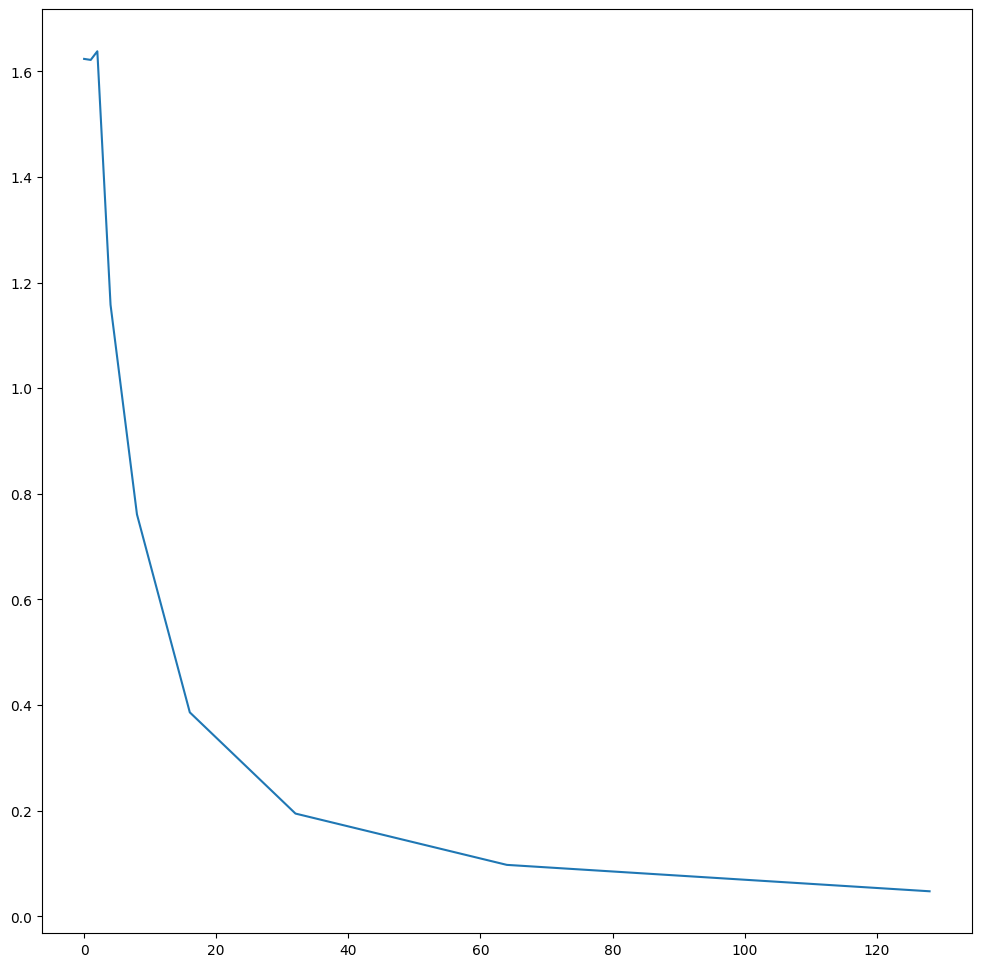

In [37]:
print(threadData)
plt.figure(figsize=(12, 12))

x = threadData["threads"]
y = threadData["mbs"]

plt.plot(x, y)